In [1]:
using Pkg, Revise
Pkg.activate("..")
# Pkg.instantiate()
using Clapeyron, cDFT, Plots

  Activating project at `/nfs/zeal_nas/home_mount/pwalker/Projects/cDFT.jl`
[ Info: Precompiling cDFT [9d464fa6-e93d-4d45-9e5b-7c20149a9a88](cache misses: wrong dep version loaded (1), mismatched flags (8))
[ Info: Precompiling cDFT [9d464fa6-e93d-4d45-9e5b-7c20149a9a88] (cache misses: wrong dep version loaded (2), mismatched flags (16))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80](cache misses: wrong dep version loaded (1), incompatible header (4))
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (2), incompatible header (8))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling PlotscDFTExt [0a290dff-ae42-5c9f-a62b-7116004d03aa](cache misses: incompatible header (2))
[ Info: Precompiling PlotscDFTExt [0a290dff-ae42-5c9f-a62b-7116004d03aa] (c

## General set-up
The cDFT and Clapeyron packages are very closely related. Clapeyron provides all the bulk information while cDFT handles all inhomogeneous calculations. The first step in any cDFT calculation is to first define the model species:

In [2]:
model = ePCSAFT(["water08"],["sodium","chloride"])

Explicit Electrolyte Model with 3 components:
 "water08"
 "sodium" (+1)
 "chloride" (-1)
Neutral Model: pharmaPCSAFT{BasicIdeal, Float64}
Ion Model: hsdDH{ConstRSP}
RSP Model: ConstRSP

In [3]:
model.neutralmodel.params.epsilon.values[2,2] = 197.737^2/70.0
model.neutralmodel.params.epsilon.values[3,3] = 70.0

70.0

From here, we want to define our system conditions. Here, we ethane within a graphite slit at 298.15 K and 10 MPa:

In [4]:
T = 298.15
p = 1e7
v = volume(model.neutralmodel, p, T,[0.9,0.05,0.05]);

With these conditions, we can now define a system structure. We now need to define our interface. We will simply use the Steele potential to represent a graphite surface.

In [5]:
L = cDFT.length_scale(model.neutralmodel) # Useful tool to obtain a characteristic length scale for the system, which can be used to non-dimensionalize the problem and choose an appropriate grid size.

width = 5L

surface = Steele(["graphite"], width);

We can now construct our structure:

In [6]:
ρb = [0.9,0.05,0.05]/v


bounds = [0.6L,-0.6L+width]

structure = cDFT.Uniform1DCart((p, T), ρb, bounds, (201,));

With this, we can now fully define our system:

In [8]:
system = ElectrolyteDFTSystem(model, structure, surface);

And initialize the profiles:

In [9]:
ρ = cDFT.initialize_profiles(system);

I've created some convenience functions to quickly visualize the density profiles:

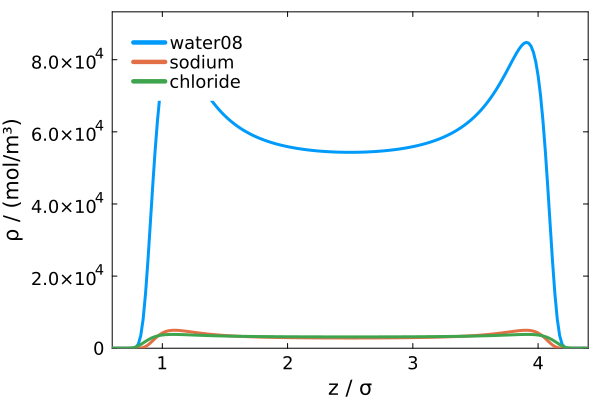

In [12]:
plot(system, ρ; y_units="mol")

Note that this profile is just an initial guess and does not correspond to the true equilibrium profile. This profile must be solved for iteratively such that the following equation is satisfied:
$$ \rho(\mathbf{r}) = \rho^b \exp\left[-\beta\left(\frac{\delta F_\mathrm{res}}{\delta \rho(\mathbf{r})}+V_\mathrm{ext}(\mathbf{r})\right)\right]$$

This is achieved using the `converge!(system, ρ)` function:

In [14]:
converge!(system, ρ);

We can see the visual difference in the converged profile:

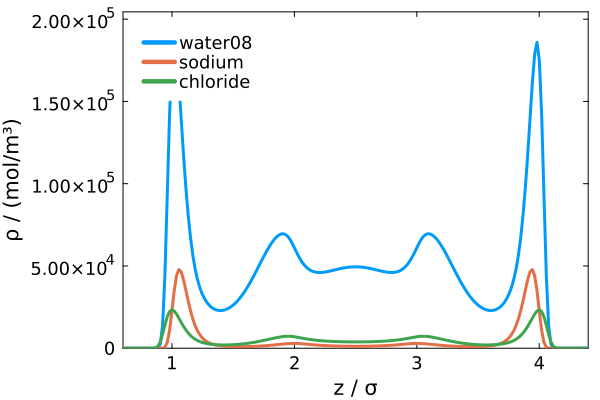

In [15]:
plot(system, ρ; y_units=:mol)